# ✅ Validation Schemes and Evaluation Metrics in Python

<a href="https://colab.research.google.com/github/rubenfonnegra/machine_learning/blob/master/Sem_05/validation_and_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> 
<a href="https://github.com/rubenfonnegra/machine_learning/blob/master/Sem_05/validation_and_metrics.ipynb" target="_parent"><img src="https://img.shields.io/badge/%E2%80%8B-Open%20in%20Github-blue?logo=github" alt="Open In Github"/></a> 


### Learning objectives

- Apply holdout validation with `train_test_split`.
- Compare three classifiers using loops.
- Display classification decision boundaries.
- Compute accuracy, confusion matrix, precision, recall, F1-score, ROC, and AUC.
- Apply `cross_val_score` and manual `StratifiedKFold`.
- Repeat the workflow for regression.
- Compute MSE, MAE, RMSE, and $R^2$.

### Documentation

- Módulo [```metrics```](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics)
- Holdout [```train_test_split```](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn.model_selection.train_test_split)
- Cross Validation [```cross_val_score```](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score), [```StratifiedKFold```](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html#sklearn.model_selection.StratifiedKFold)

---

> **📘 Machine Learning**  
> **Author:** Rubén D. Fonnegra, Ph.D. \
> **Institution:** Institución Universitaria Pascual Bravo  
> © 2026 · Educational use with attribution

### Imports

In [11]:
#@markdown #### **🛠️⚙️📦 Install complementary dependencies**. 

from tqdm.auto import tqdm
import subprocess, time, sys

LIB = "MLTools-1.2-py3-none-any.whl"
URL = "https://drive.google.com/uc?id=18Y834Tvtj_-Px9yNmbAB4yV4L0gcIZ20"

commands = [
    ("📦 Downloading resources", ["gdown", URL, "-O", LIB], 35),
    ("🔧 Installing dependencies", [sys.executable, "-m", "pip", "install", "-q", LIB], 55),
    ("🧹 Finishing", ["rm", "-f", LIB], 10)
]

print("⚙️ Iniciando configuración del entorno...\n")

try:
    with tqdm(total=100, desc="Preparando", bar_format="{desc}: {bar} {n:.0f}%") as bar:
        for label, command, weight in commands:
            bar.set_description(label)
            subprocess.run(command, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
            for _ in range(weight):
                time.sleep(0.01)
                bar.update(1)

    print("\n✅ Configuración completada correctamente. Puede comenzar la actividad.")

except subprocess.CalledProcessError as e:
    print("\n❌ Error durante la configuración")
    print(f"Exit code: {e.returncode}")

    if e.stdout:
        print("\n📤 STDOUT:")
        print(e.stdout)

    if e.stderr:
        print("\n🔍 STDERR:")
        print(e.stderr)

    print("\n❌ No fue posible configurar el entorno. Ejecute nuevamente la celda.")


⚙️ Iniciando configuración del entorno...



Preparando:            0%


✅ Configuración completada correctamente. Puede comenzar la actividad.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVR
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

from MLTools import generate_isotropic_blobs, generate_nonlinear_regression, plot_decision_boundaries, plot_regression_dataset

## Part I. Classification

### Generate classification data

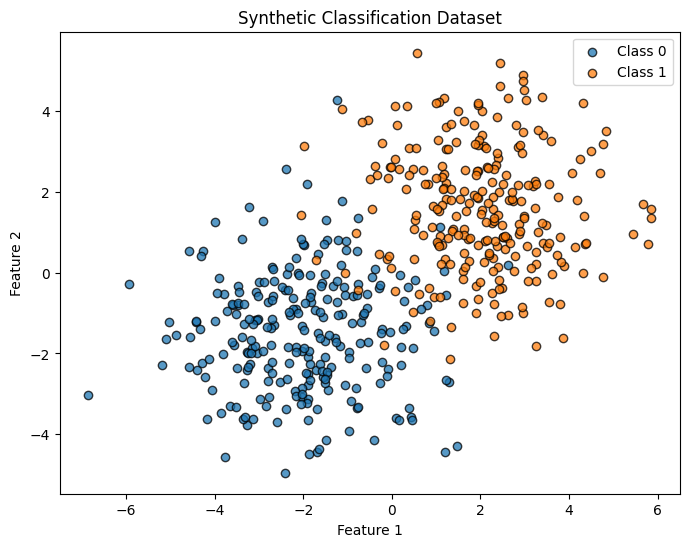

In [2]:
X_class, y_class = generate_isotropic_blobs(
    n_samples=500,
    centers=[(-2.0, -1.5), (2.0, 1.5)],
    cluster_std=1.5,
    random_state=42
)

plt.figure(figsize=(8, 6))
for label in np.unique(y_class):
    mask = y_class == label
    plt.scatter(
        X_class[mask, 0],
        X_class[mask, 1],
        label=f"Class {label}",
        edgecolors="black",
        alpha=0.75
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Classification Dataset")
plt.legend()
plt.show()


### Holdout

In [ ]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=0.30,
    random_state=42,
    stratify=y_class
)

print("Training samples:", Xc_train.shape)
print("Testing samples:", Xc_test.shape) 


Training samples: (350, 2)
Testing samples: (150, 2)


### Training classifiers

In [8]:
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42)
}

fitted_classifiers = {}
class_predictions = {}
class_scores = {}

for name, classifier in classifiers.items():
    classifier.fit(Xc_train, yc_train)
    fitted_classifiers[name] = classifier

    predictions = classifier.predict(Xc_test)
    class_predictions[name] = predictions

    if hasattr(classifier, "predict_proba"):
        scores = classifier.predict_proba(Xc_test)[:, 1]
    else:
        scores = classifier.decision_function(Xc_test)

    class_scores[name] = scores


### Decision boundaries on the test data

c:\Users\WINDOWS 11\Documents\antigravity\machine_learning\.venv\lib\site-packages\MLTools\classification_generators.py:279: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(data[mask, 0], data[mask, 1], label=label, edgecolors="black", alpha=0.75, cmap="Paired")


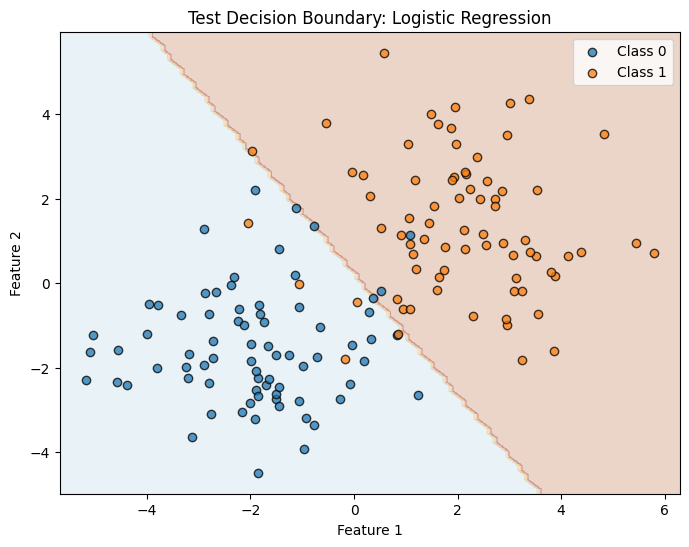

c:\Users\WINDOWS 11\Documents\antigravity\machine_learning\.venv\lib\site-packages\MLTools\classification_generators.py:279: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(data[mask, 0], data[mask, 1], label=label, edgecolors="black", alpha=0.75, cmap="Paired")


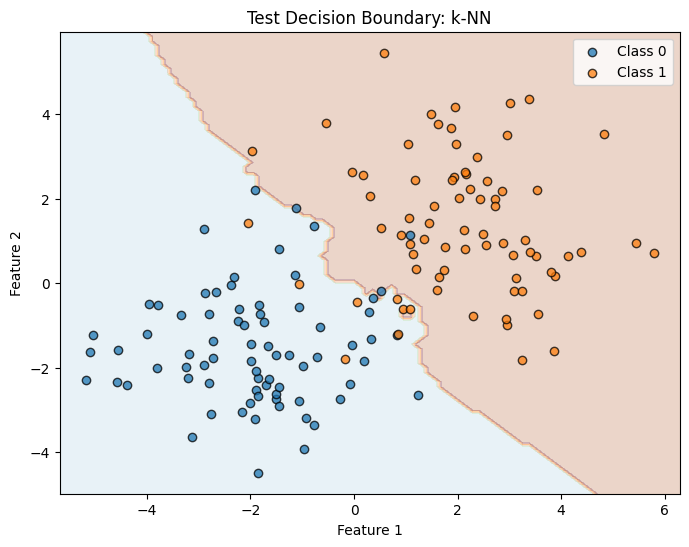

c:\Users\WINDOWS 11\Documents\antigravity\machine_learning\.venv\lib\site-packages\MLTools\classification_generators.py:279: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(data[mask, 0], data[mask, 1], label=label, edgecolors="black", alpha=0.75, cmap="Paired")


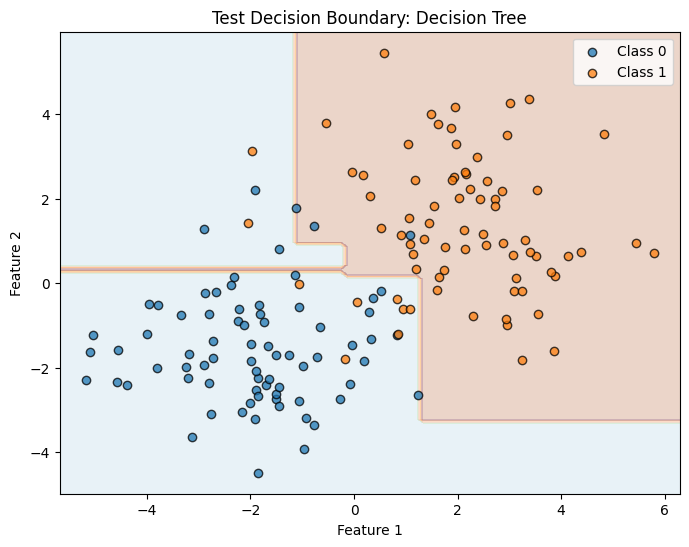

In [9]:
for name, classifier in fitted_classifiers.items():
    plot_decision_boundaries(
        model=classifier,
        X=Xc_test,
        y=yc_test,
        resolution=100,
        padding=0.5,
        feature_names=("Feature 1", "Feature 2"),
        title=f"Test Decision Boundary: {name}"
    )
    plt.show()


### Classification metrics

In [10]:
classification_rows = []

for name in fitted_classifiers:
    pred = class_predictions[name]
    scores = class_scores[name]

    classification_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(yc_test, pred),
        "Precision": precision_score(yc_test, pred),
        "Recall": recall_score(yc_test, pred),
        "F1-score": f1_score(yc_test, pred),
        "AUC": roc_auc_score(yc_test, scores)
    })

classification_results = pd.DataFrame(classification_rows)
classification_results


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.946667,0.958904,0.933333,0.945946,0.988089
1,k-NN,0.926667,0.957143,0.893333,0.924138,0.972444
2,Decision Tree,0.920000,0.956522,0.880000,0.916667,0.943911


### Confusion matrices

Logistic Regression


,Predicted 0,Predicted 1
Actual 0,72,3
Actual 1,5,70


k-NN


,Predicted 0,Predicted 1
Actual 0,72,3
Actual 1,8,67


Decision Tree


,Predicted 0,Predicted 1
Actual 0,72,3
Actual 1,9,66


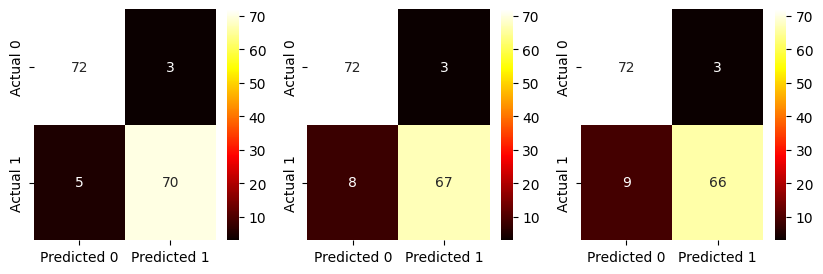

In [12]:
_, axes = plt.subplots(1,3,figsize=(10,3))

for ax, name in zip(axes, fitted_classifiers):
    cm = confusion_matrix(yc_test, class_predictions[name])
    sns.heatmap(cm, annot=True, cmap='hot', ax=ax,
                xticklabels=["Predicted 0", "Predicted 1"],
                yticklabels=["Actual 0", "Actual 1"],)

    print(name)
    display(pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    ))


### ROC curves

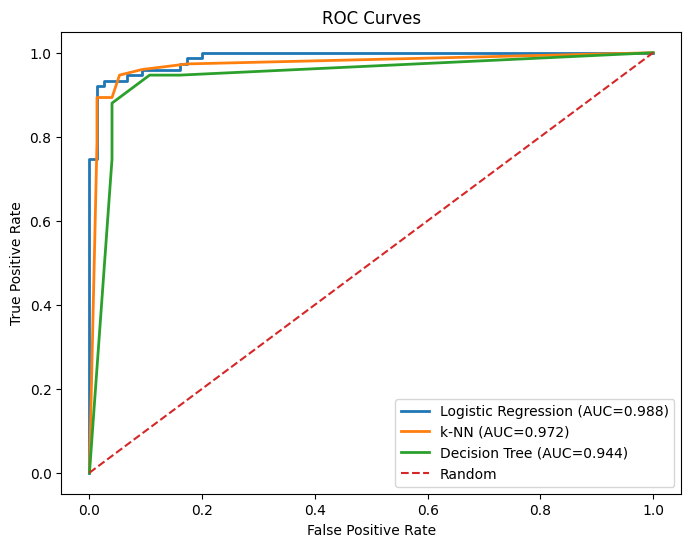

In [18]:
plt.figure(figsize=(8, 6))

for name in fitted_classifiers:
    fpr, tpr, _ = roc_curve(yc_test, class_scores[name])
    auc_value = roc_auc_score(yc_test, class_scores[name])

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc_value:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


### Classification cross-validation with `cross_val_score`

In [19]:
classification_cv_rows = []

for name, classifier in classifiers.items():
    accuracy_scores = cross_val_score(
        classifier, X_class, y_class,
        cv=5, scoring="accuracy"
    )
    f1_scores = cross_val_score(
        classifier, X_class, y_class,
        cv=5, scoring="f1"
    )
    auc_scores = cross_val_score(
        classifier, X_class, y_class,
        cv=5, scoring="roc_auc"
    )

    classification_cv_rows.append({
        "Model": name,
        "Mean accuracy": accuracy_scores.mean(),
        "Std accuracy": accuracy_scores.std(),
        "Mean F1": f1_scores.mean(),
        "Std F1": f1_scores.std(),
        "Mean AUC": auc_scores.mean(),
        "Std AUC": auc_scores.std()
    })

classification_cv_results = pd.DataFrame(classification_cv_rows)
classification_cv_results


,Model,Mean accuracy,Std accuracy,Mean F1,Std F1,Mean AUC,Std AUC
0,Logistic Regression,0.950,0.030332,0.949566,0.030719,0.99008,0.007112
1,k-NN,0.946,0.016248,0.944861,0.017038,0.97568,0.014627
2,Decision Tree,0.946,0.022450,0.945807,0.022757,0.96604,0.023777


### Manual classification CV with `StratifiedKFold.split`

In [20]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

manual_class_rows = []

for fold, (train_idx, valid_idx) in enumerate(
    skf.split(X_class, y_class),
    start=1
):
    X_train_fold = X_class[train_idx]
    X_valid_fold = X_class[valid_idx]
    y_train_fold = y_class[train_idx]
    y_valid_fold = y_class[valid_idx]

    for name, classifier in classifiers.items():
        classifier.fit(X_train_fold, y_train_fold)
        pred = classifier.predict(X_valid_fold)

        if hasattr(classifier, "predict_proba"):
            scores = classifier.predict_proba(X_valid_fold)[:, 1]
        else:
            scores = classifier.decision_function(X_valid_fold)

        manual_class_rows.append({
            "Fold": fold,
            "Model": name,
            "Accuracy": accuracy_score(y_valid_fold, pred),
            "Precision": precision_score(y_valid_fold, pred),
            "Recall": recall_score(y_valid_fold, pred),
            "F1-score": f1_score(y_valid_fold, pred),
            "AUC": roc_auc_score(y_valid_fold, scores)
        })

manual_class_df = pd.DataFrame(manual_class_rows)
manual_class_df.head()


,Fold,Model,Accuracy,Precision,Recall,F1-score,AUC
0,1,Logistic Regression,0.96,0.960000,0.96,0.960000,0.9876
1,1,k-NN,0.96,0.960000,0.96,0.960000,0.9636
2,1,Decision Tree,0.93,0.921569,0.94,0.930693,0.9650
3,2,Logistic Regression,0.94,0.978261,0.90,0.937500,0.9912
4,2,k-NN,0.94,0.958333,0.92,0.938776,0.9794


In [21]:
manual_class_summary = (
    manual_class_df
    .groupby("Model")
    .agg({
        "Accuracy": ["mean", "std"],
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "F1-score": ["mean", "std"],
        "AUC": ["mean", "std"]
    })
)

manual_class_summary


Accuracy           Precision           Recall            \
                        mean       std      mean       std   mean       std   
Model                                                                         
Decision Tree          0.940  0.007071  0.944201  0.020717  0.936  0.021909   
Logistic Regression    0.952  0.010954  0.959652  0.013536  0.944  0.026077   
k-NN                   0.952  0.019235  0.963166  0.016983  0.940  0.028284   

                     F1-score                AUC            
                         mean       std     mean       std  
Model                                                       
Decision Tree        0.939738  0.007118  0.96808  0.010660  
Logistic Regression  0.951500  0.011673  0.99128  0.003788  
k-NN                 0.951304  0.019676  0.97884  0.010839

## Part II. Regression

### Generate regression data

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Synthetic Nonlinear Regression Dataset'}, xlabel='x', ylabel='y'>)

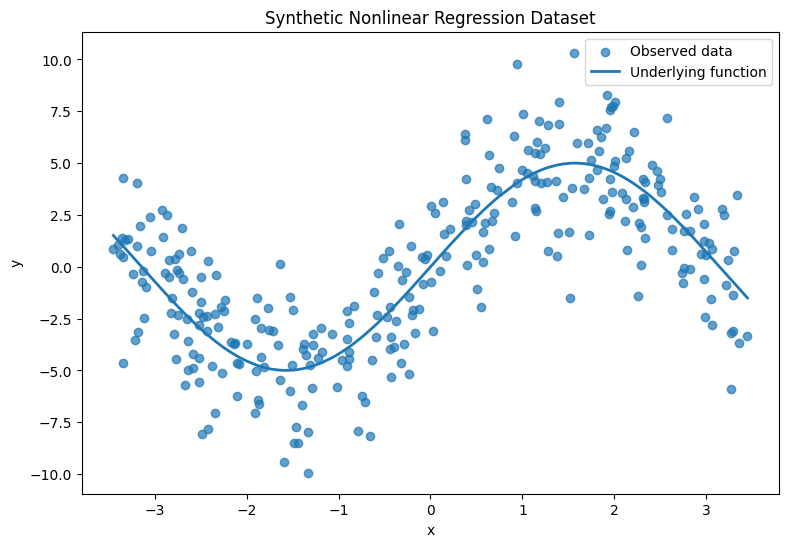

In [4]:
X_reg, y_reg, y_true = generate_nonlinear_regression(
    n_samples=300,
    x_range=(-3.5, 3.5),
    function="sin",
    noise=2.2,
    random_state=42
)

plot_regression_dataset(
    X_reg,
    y_reg,
    y_true=y_true,
    title="Synthetic Nonlinear Regression Dataset"
)

### Regression holdout

In [5]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.30,
    random_state=42
)

regressors = {
    "Linear Regression": LinearRegression(),
    "k-NN Regressor": KNeighborsRegressor(n_neighbors=9),
    "SVR": SVR(kernel="rbf", C=10.0, epsilon=1.0, gamma="scale")
}

fitted_regressors = {}
reg_predictions = {}

for name, regressor in regressors.items():
    regressor.fit(Xr_train, yr_train)
    fitted_regressors[name] = regressor
    reg_predictions[name] = regressor.predict(Xr_test)


### Regression curves on the test data

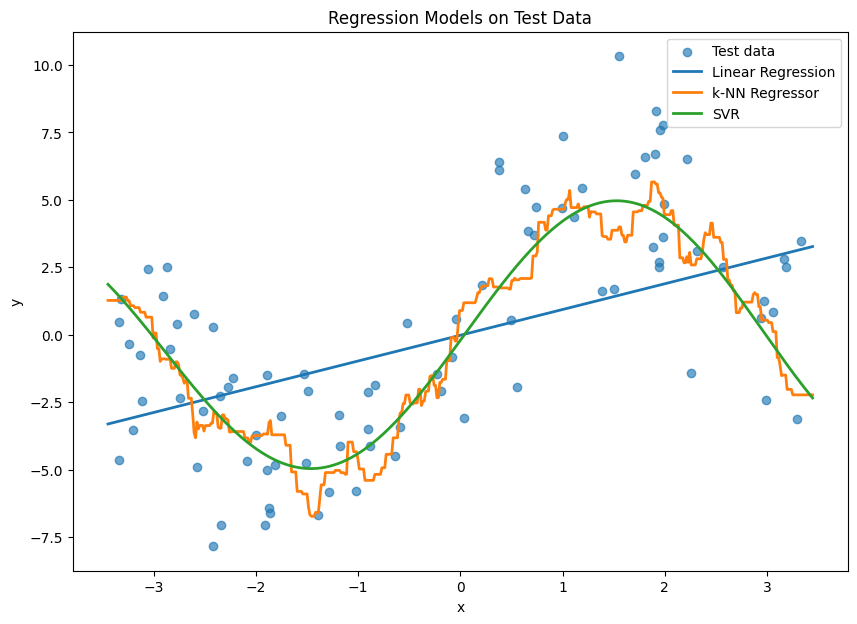

In [6]:
x_grid = np.linspace(
    X_reg[:, 0].min(),
    X_reg[:, 0].max(),
    500
).reshape(-1, 1)

plt.figure(figsize=(10, 7))
plt.scatter(
    Xr_test[:, 0],
    yr_test,
    alpha=0.65,
    label="Test data"
)

for name, regressor in fitted_regressors.items():
    plt.plot(
        x_grid[:, 0],
        regressor.predict(x_grid),
        linewidth=2,
        label=name
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression Models on Test Data")
plt.legend()
plt.show()


### Regression metrics

In [7]:
regression_rows = []

for name in fitted_regressors:
    pred = reg_predictions[name]
    mse = mean_squared_error(yr_test, pred)

    regression_rows.append({
        "Model": name,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(yr_test, pred),
        "R²": r2_score(yr_test, pred)
    })

regression_results = pd.DataFrame(regression_rows)
regression_results


,Model,MSE,RMSE,MAE,R²
0,Linear Regression,11.993155,3.463113,2.838982,0.317243
1,k-NN Regressor,6.757313,2.599483,2.094065,0.615314
2,SVR,6.015764,2.452705,1.975494,0.657529


### Residual plots

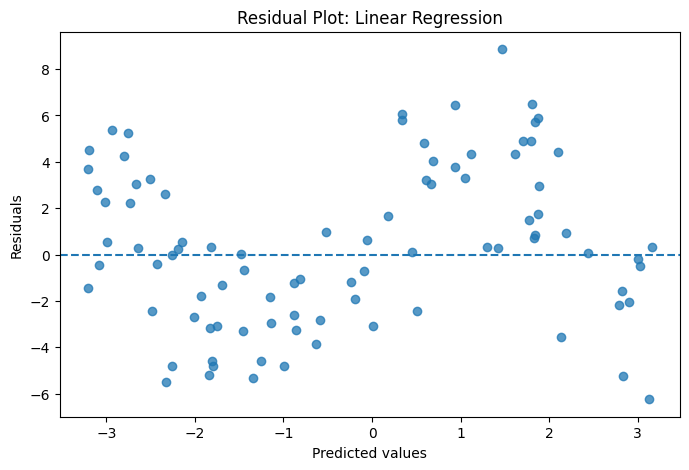

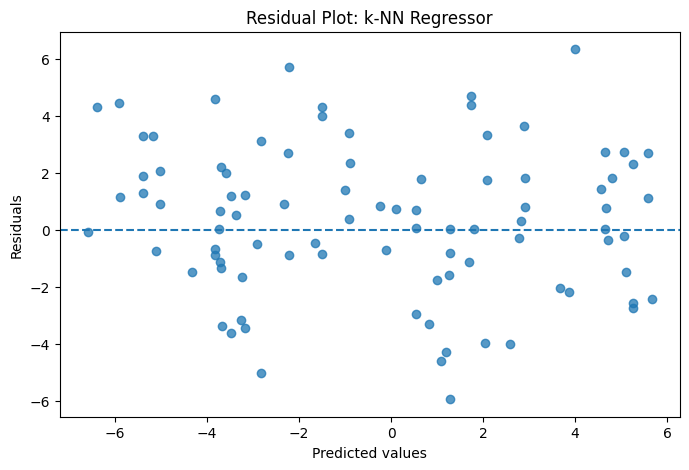

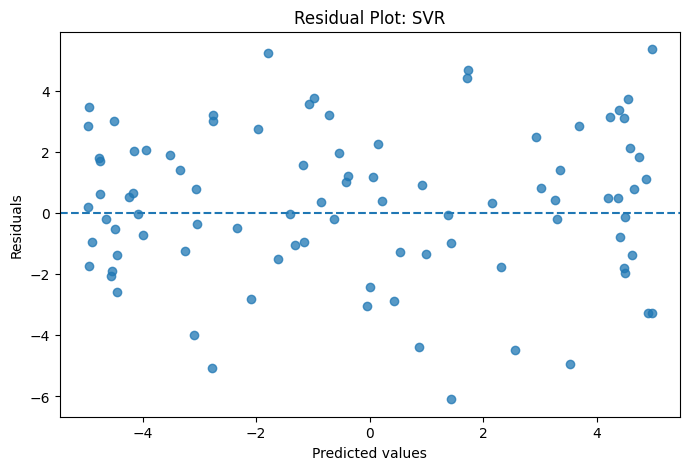

In [8]:
for name in fitted_regressors:
    pred = reg_predictions[name]
    residuals = yr_test - pred

    plt.figure(figsize=(8, 5))
    plt.scatter(pred, residuals, alpha=0.75)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot: {name}")
    plt.show()


### Regression cross-validation with `cross_val_score`

In [9]:
regression_cv_rows = []

for name, regressor in regressors.items():
    neg_mse = cross_val_score(
        regressor, X_reg, y_reg,
        cv=5, scoring="neg_mean_squared_error"
    )
    neg_mae = cross_val_score(
        regressor, X_reg, y_reg,
        cv=5, scoring="neg_mean_absolute_error"
    )
    r2_scores = cross_val_score(
        regressor, X_reg, y_reg,
        cv=5, scoring="r2"
    )

    mse_scores = -neg_mse
    mae_scores = -neg_mae

    regression_cv_rows.append({
        "Model": name,
        "Mean MSE": mse_scores.mean(),
        "Std MSE": mse_scores.std(),
        "Mean RMSE": np.sqrt(mse_scores).mean(),
        "Mean MAE": mae_scores.mean(),
        "Std MAE": mae_scores.std(),
        "Mean R²": r2_scores.mean(),
        "Std R²": r2_scores.std()
    })

regression_cv_results = pd.DataFrame(regression_cv_rows)
regression_cv_results


,Model,Mean MSE,Std MSE,Mean RMSE,Mean MAE,Std MAE,Mean R²,Std R²
0,Linear Regression,20.216578,5.539672,4.442820,3.786769,0.733621,-2.263593,1.428320
1,k-NN Regressor,10.968573,6.239049,3.191818,2.635239,0.798982,-0.570938,0.770921
2,SVR,7.511300,4.231105,2.656372,2.171904,0.582151,-0.085933,0.512538


### Manual regression CV with `KFold.split`

In [11]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

manual_reg_rows = []

for fold, (train_idx, valid_idx) in enumerate(
    kf.split(X_reg),
    start=1
):
    X_train_fold = X_reg[train_idx]
    X_valid_fold = X_reg[valid_idx]
    y_train_fold = y_reg[train_idx]
    y_valid_fold = y_reg[valid_idx]

    for name, regressor in regressors.items():
        regressor.fit(X_train_fold, y_train_fold)
        pred = regressor.predict(X_valid_fold)
        mse = mean_squared_error(y_valid_fold, pred)

        manual_reg_rows.append({
            "Fold": fold,
            "Model": name,
            "MSE": mse,
            "RMSE": np.sqrt(mse),
            "MAE": mean_absolute_error(y_valid_fold, pred),
            "R²": r2_score(y_valid_fold, pred)
        })

manual_reg_df = pd.DataFrame(manual_reg_rows)
manual_reg_df.head()


,Fold,Model,MSE,RMSE,MAE,R²
0,1,Linear Regression,13.267960,3.642521,2.999040,0.347190
1,1,k-NN Regressor,7.526795,2.743501,2.215305,0.629667
2,1,SVR,6.955615,2.637350,2.109315,0.657770
3,2,Linear Regression,11.220307,3.349673,2.733683,0.289403
4,2,k-NN Regressor,4.602443,2.145331,1.623167,0.708521


In [ ]:
manual_reg_summary = (
    manual_reg_df
    .groupby("Model")
    .agg({
        "MSE": ["mean", "std"],
        "RMSE": ["mean", "std"],
        "MAE": ["mean", "std"],
        "R²": ["mean", "std"]
    })
)
    
manual_reg_summary


MSE                RMSE                 MAE  \
                        mean       std      mean       std      mean   
Model                                                                  
Linear Regression  11.926414  1.748141  3.445601  0.260394  2.806999   
SVR                 5.025231  1.147904  2.231019  0.244403  1.777270   
k-NN Regressor      5.278241  1.262156  2.285900  0.257152  1.841864   

                                   R²            
                        std      mean       std  
Model                                            
Linear Regression  0.261457  0.250325  0.072889  
SVR                0.198196  0.685830  0.043114  
k-NN Regressor     0.225565  0.670214  0.046781

### Holdout vs Cross-Validation

#### Holdout
- Simple and fast
- Depends on one split
- Useful for a final test set

#### k-Fold Cross-Validation
- Uses several train/validation splits
- Reports mean performance and variability
- Usually more stable on small and medium datasets
- Stratified k-Fold preserves class proportions in each fold (designed for classification)


### Practice Exercises

1. Add another classifier and regressor.
2. Compare the ranking produced by holdout and cross-validation.

In [ ]:
# Your code here

---


## 📄 Attribution

This notebook was developed by **Rubén D. Fonnegra** as educational material for Machine Learning courses at **Institución Universitaria Pascual Bravo**.
You may use, share, and adapt this material for educational purposes, provided that appropriate credit is given to the original author.

**Suggested citation:**
> Fonnegra Tarazona, R. D. (2026). *Validation and metrics: Machine Learning Notebook*. Institución Universitaria Pascual Bravo.